# Explore the distribution of the yam_suitablity variable

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../data/processed/merged_18_19_21.csv')

<Axes: xlabel='yam_suitability', ylabel='Count'>

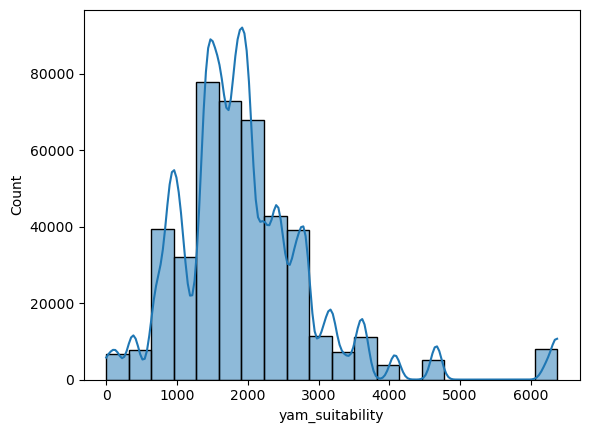

In [3]:
# graph the distribution of the 'yam_suitability' column
sns.histplot(df['yam_suitability'], bins=20, kde=True)

In [4]:
# make a summary of the 'yam_suitability' column
summary = df['yam_suitability'].describe()
summary

count    433172.000000
mean       1955.901618
std        1012.717650
min           0.000000
25%        1409.595506
50%        1839.981818
75%        2388.642857
max        6369.818182
Name: yam_suitability, dtype: float64

# Make a heatmap between BMI and price

In [5]:
df.head()

,regcode,provhuc,enns_year,hhnum,member_code,fwgti_natl_var,fwgti_prov,rep_natl,rep_prov,ms_psucode,...,anthro_group,mos_lactation,mos_preg,var_value_int,value_label_lower_cleaned,name_lower_cleaned,geometry,bmi,yam_suitability,ube_price_1kg
0,1,1,2019,45958.0,1,2240.2327,111.251910,10,13,82.0,...,4,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,19.503986,1946.571429,56.08
1,1,1,2019,45958.0,2,2287.2642,109.743670,10,13,82.0,...,4,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,20.722483,1946.571429,56.08
2,1,1,2019,45958.0,3,2757.3613,66.695587,10,13,82.0,...,5,NaN,6.0,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,31.894474,1946.571429,56.08
3,1,1,2019,45958.0,4,3146.1538,83.465775,10,13,82.0,...,1,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,13.331434,1946.571429,56.08
4,1,1,2019,45959.0,1,2090.6460,71.073441,10,13,82.0,...,4,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,21.684146,1946.571429,56.08


In [6]:
df_small = df[['bmi', 'yam_suitability', 'ube_price_1kg', 'provhuc']]

In [7]:
# convert each column in df_small_scaled to a scale from 0 to 1 except for the 'provhuc' column
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_small_scaled = df_small.copy()
df_small_scaled[['bmi', 'yam_suitability', 'ube_price_1kg']] = scaler.fit_transform(df_small_scaled[['bmi', 'yam_suitability', 'ube_price_1kg']])

In [8]:
df_small_scaled.head()

,bmi,yam_suitability,ube_price_1kg,provhuc
0,0.216118,0.305593,0.0,1
1,0.236493,0.305593,0.0,1
2,0.423305,0.305593,0.0,1
3,0.112905,0.305593,0.0,1
4,0.252574,0.305593,0.0,1


In [11]:
import statsmodels.formula.api as smf

model = smf.ols(
    'bmi ~ ube_price_1kg + yam_suitability + ube_price_1kg:yam_suitability',
    data=df_small_scaled
).fit()

print(model.summary())
# Extract: a = coef on ube_price_1kg
#          b = coef on yam_suitability  
#          c = coef on the interaction term

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     681.5
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:55:40   Log-Likelihood:             4.4235e+05
No. Observations:              432313   AIC:                        -8.847e+05
Df Residuals:                  432309   BIC:                        -8.846e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [12]:
df_small.head()

,bmi,yam_suitability,ube_price_1kg,provhuc
0,19.503986,1946.571429,56.08,1
1,20.722483,1946.571429,56.08,1
2,31.894474,1946.571429,56.08,1
3,13.331434,1946.571429,56.08,1
4,21.684146,1946.571429,56.08,1


In [13]:
# sort all columns in df_small in ascending order
df_small_sorted = df_small.sort_values(by=['bmi', 'yam_suitability', 'ube_price_1kg', 'provhuc'])
df_small_sorted.head()

,bmi,yam_suitability,ube_price_1kg,provhuc
217185,6.579307,1698.000000,56.08,60
121867,6.815054,1451.652174,59.56,37
386425,6.970380,2697.000000,59.56,111
368886,7.170820,1596.543478,56.08,108
373875,7.183510,1839.981818,59.56,109


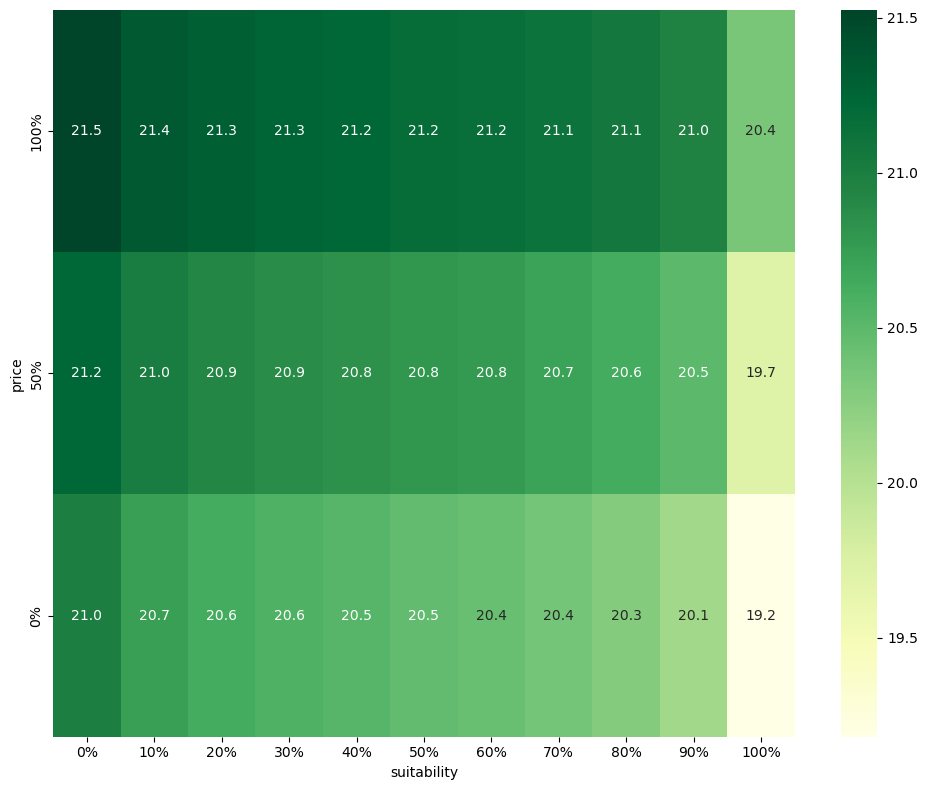

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Get the quantile values (every 10th percentile) for each variable
percentiles = np.arange(0, 101, 10)  # [0, 10, 20, ..., 100]
three_splits = [0, 50, 100]  # for 3 splits

suitability_quantiles = np.percentile(df['yam_suitability'], percentiles)
price_quantiles = np.percentile(df['ube_price_1kg'], three_splits)

# 2. Build the grid and fill with predicted BMI using your regression equation
def predict_bmi(suitability, price):
    return (17.153697 
            + (-0.001014 * suitability) 
            + (0.068515 * price) 
            + (0.000013 * suitability * price))

# 3. Create an 11x11 matrix of predicted values
bmi_matrix = np.zeros((len(price_quantiles), len(suitability_quantiles)))

for i, price in enumerate(price_quantiles):
    for j, suit in enumerate(suitability_quantiles):
        bmi_matrix[i, j] = predict_bmi(suit, price)

# 4. Build DataFrames with percentile labels as axis ticks
labels = [f"{p}%" for p in percentiles]
price_labels = [f"{p}%" for p in three_splits]

bmi_df = pd.DataFrame(
    bmi_matrix[::-1],  # flip so 100% is at the top
    index=price_labels[::-1],
    columns=labels
)

# 5. Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(bmi_df, ax=ax, cmap='YlGn', annot=True, fmt='.1f')

ax.set_xlabel('suitability')
ax.set_ylabel('price')
plt.tight_layout()
plt.savefig(os.path.join('../output', 'heatmap.svg'), bbox_inches='tight')
plt.show()

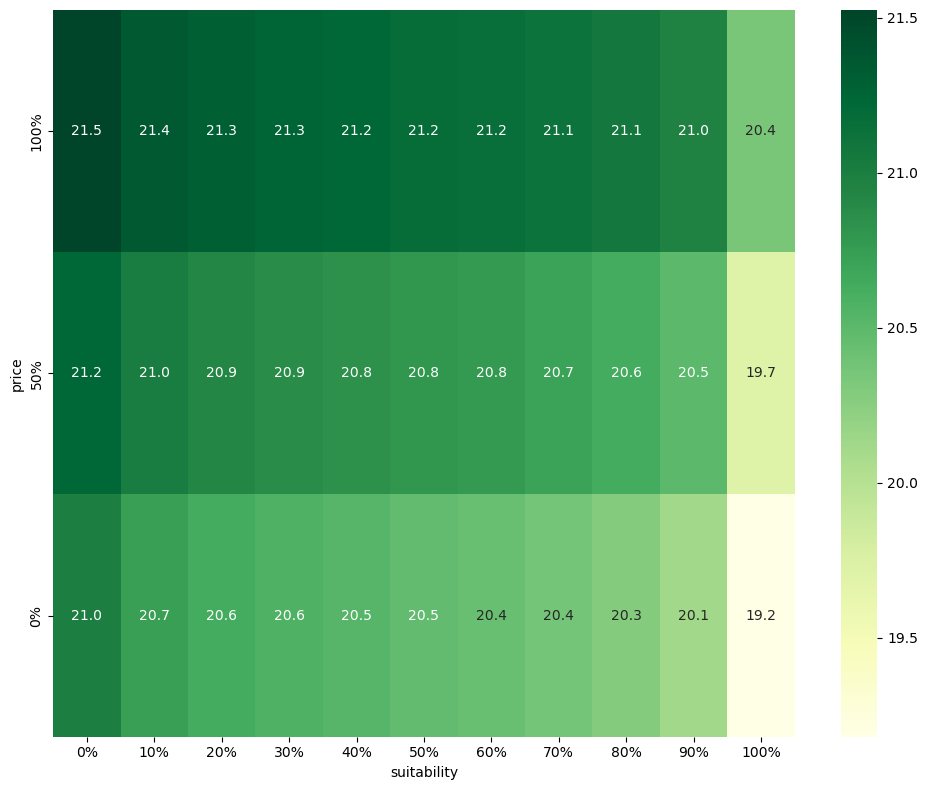

In [4]:
### EXPORT HEATMAP AS PNG

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Get the quantile values (every 10th percentile) for each variable
percentiles = np.arange(0, 101, 10)  # [0, 10, 20, ..., 100]
three_splits = [0, 50, 100]  # for 3 splits

suitability_quantiles = np.percentile(df['yam_suitability'], percentiles)
price_quantiles = np.percentile(df['ube_price_1kg'], three_splits)

# 2. Build the grid and fill with predicted BMI using your regression equation
def predict_bmi(suitability, price):
    return (17.153697 
            + (-0.001014 * suitability) 
            + (0.068515 * price) 
            + (0.000013 * suitability * price))

# 3. Create an 11x11 matrix of predicted values
bmi_matrix = np.zeros((len(price_quantiles), len(suitability_quantiles)))

for i, price in enumerate(price_quantiles):
    for j, suit in enumerate(suitability_quantiles):
        bmi_matrix[i, j] = predict_bmi(suit, price)

# 4. Build DataFrames with percentile labels as axis ticks
labels = [f"{p}%" for p in percentiles]
price_labels = [f"{p}%" for p in three_splits]

bmi_df = pd.DataFrame(
    bmi_matrix[::-1],  # flip so 100% is at the top
    index=price_labels[::-1],
    columns=labels
)

# 5. Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(bmi_df, ax=ax, cmap='YlGn', annot=True, fmt='.1f')

ax.set_xlabel('suitability')
ax.set_ylabel('price')
plt.tight_layout()
plt.savefig(os.path.join('../output', 'heatmap.png'), bbox_inches='tight', dpi=300)
plt.show()

# Make a graph of the province boundaries on top of the suitability map

In [4]:
df.head()

,regcode,provhuc,enns_year,hhnum,member_code,fwgti_natl_var,fwgti_prov,rep_natl,rep_prov,ms_psucode,...,anthro_group,mos_lactation,mos_preg,var_value_int,value_label_lower_cleaned,name_lower_cleaned,geometry,bmi,yam_suitability,ube_price_1kg
0,1,1,2019,45958.0,1,2240.2327,111.251910,10,13,82.0,...,4,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,19.503986,1946.571429,56.08
1,1,1,2019,45958.0,2,2287.2642,109.743670,10,13,82.0,...,4,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,20.722483,1946.571429,56.08
2,1,1,2019,45958.0,3,2757.3613,66.695587,10,13,82.0,...,5,NaN,6.0,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,31.894474,1946.571429,56.08
3,1,1,2019,45958.0,4,3146.1538,83.465775,10,13,82.0,...,1,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,13.331434,1946.571429,56.08
4,1,1,2019,45959.0,1,2090.6460,71.073441,10,13,82.0,...,4,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,21.684146,1946.571429,56.08


In [5]:
# load in the grouped csv file
grouped_df = pd.read_csv('../data/processed/merged_18_19_21_grouped.csv')

In [6]:
grouped_df.head()

,regcode,provhuc,enns_year,hhnum,member_code,fwgti_natl_var,fwgti_prov,rep_natl,rep_prov,ms_psucode,...,hip,anthro_group,mos_lactation,mos_preg,var_value_int,value_label_lower_cleaned,name_lower_cleaned,geometry,bmi,yam_suitability
0,1,1,2019,45958.0,1,2240.2327,111.251910,10,13,82.0,...,88.233330,4,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,19.503986,1946.571429
1,1,1,2019,45958.0,2,2287.2642,109.743670,10,13,82.0,...,86.666664,4,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,20.722483,1946.571429
2,1,1,2019,45958.0,3,2757.3613,66.695587,10,13,82.0,...,NaN,5,NaN,6.0,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,31.894474,1946.571429
3,1,1,2019,45958.0,4,3146.1538,83.465775,10,13,82.0,...,NaN,1,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,13.331434,1946.571429
4,1,1,2019,45959.0,1,2090.6460,71.073441,10,13,82.0,...,92.166664,4,NaN,NaN,1,ilocos norte,ilocos norte,POLYGON ((120.42613947039311 17.89403592493226...,21.684146,1946.571429


In [16]:
import sys
!{sys.executable} -m pip install rasterio

  Using cached affine-2.4.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 9.7 MB/s  0:00:02m0:00:01:00:01
Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
Using cached affine-2.4.0-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [rasterio]4/5 [rasterio]


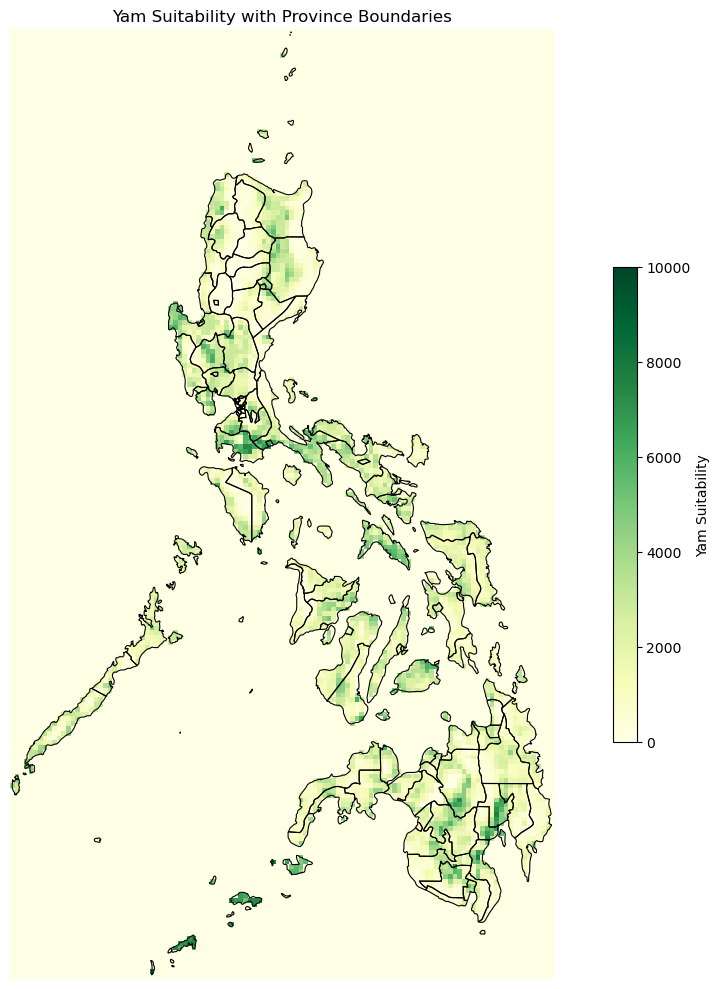

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
from rasterio.mask import mask

provinces = gpd.read_file('../data/raw/ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp')
provinces = provinces[provinces['admin'] == 'Philippines']

# Crop raster to province extent
with rasterio.open('../data/raw/suit_data/DATA_GAEZ-V5_MAPSET_RES05-SXX_GAEZ-V5.RES05-SXX.HP0120.AGERA5.HIST.YAM.LRLM.tif') as src:
    # Make sure CRS matches
    provinces_reproj = provinces.to_crs(src.crs)
    
    # Crop raster to province shapes
    cropped, transform = mask(src, provinces_reproj.geometry, crop=True)
    meta = src.meta.update({
        'height': cropped.shape[1],
        'width': cropped.shape[2],
        'transform': transform
    })

fig, ax = plt.subplots(figsize=(12, 10))

# Plot cropped raster
img = show(cropped, transform=transform, ax=ax, cmap='YlGn', vmin=0, vmax=10000)
plt.colorbar(img.get_images()[0], ax=ax, label='Yam Suitability', shrink=0.5)


# Overlay province boundaries
provinces_reproj.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)

ax.set_title('Yam Suitability with Province Boundaries')
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join('../output', 'suitmap_green.svg'), bbox_inches='tight')
plt.show()